In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../src')
from preprocessing import load_and_preprocess
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

X_res, X_test, y_res, y_test, scaler = load_and_preprocess(
    '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

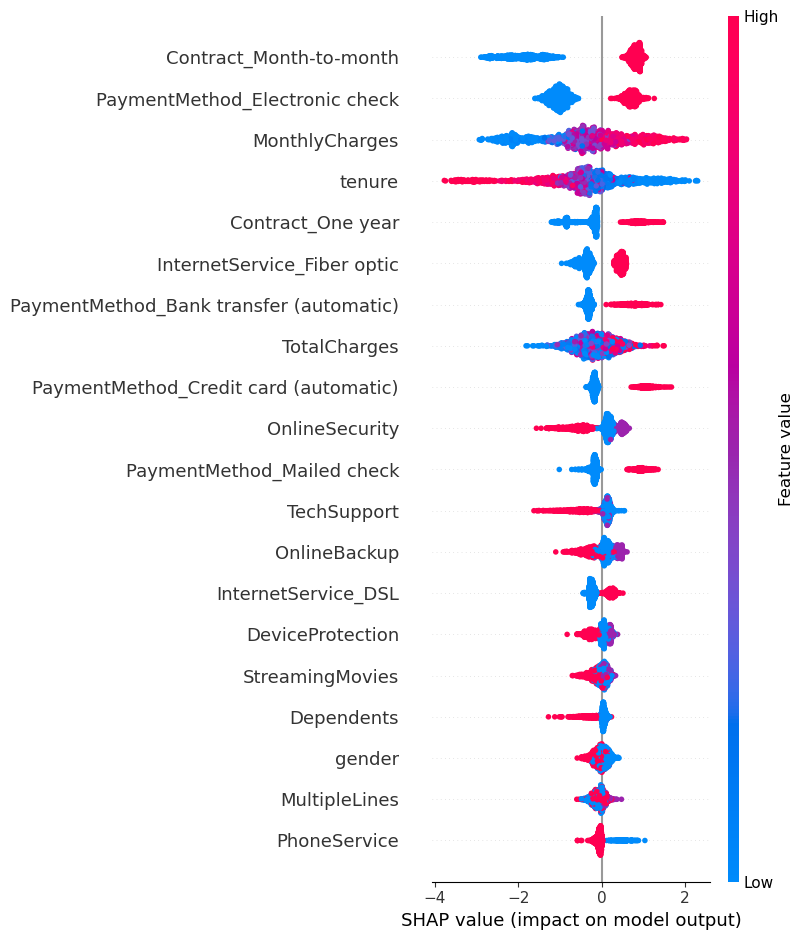

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Get feature names
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'])
feature_names = df.drop(['customerID','Churn'], axis=1).columns.tolist()

shap.summary_plot(shap_values, X_test, feature_names=feature_names)

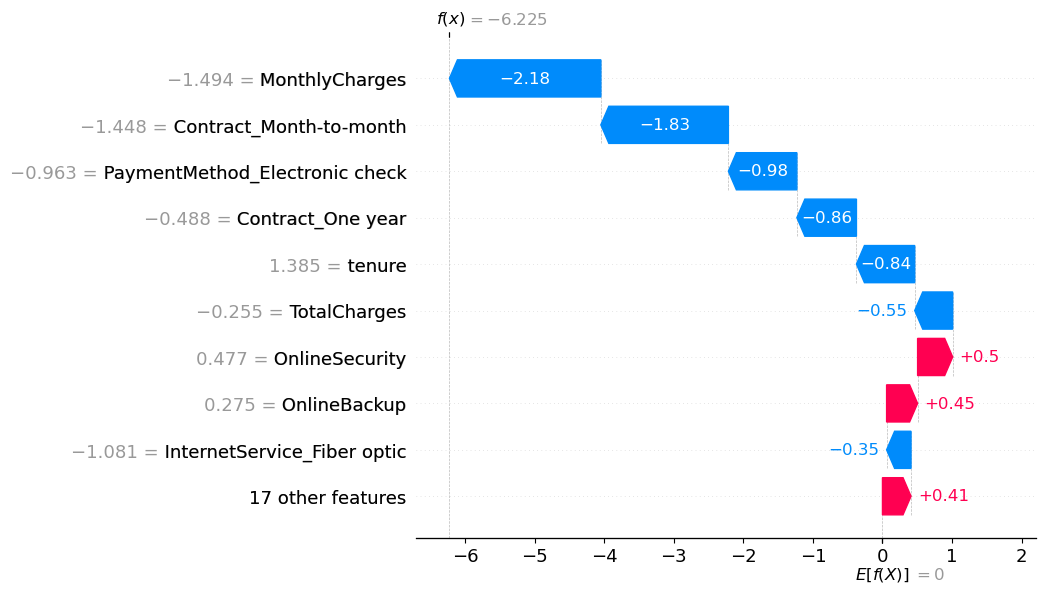

In [7]:
# Explains prediction for customer at index 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test[0],
        feature_names=feature_names
    )
)

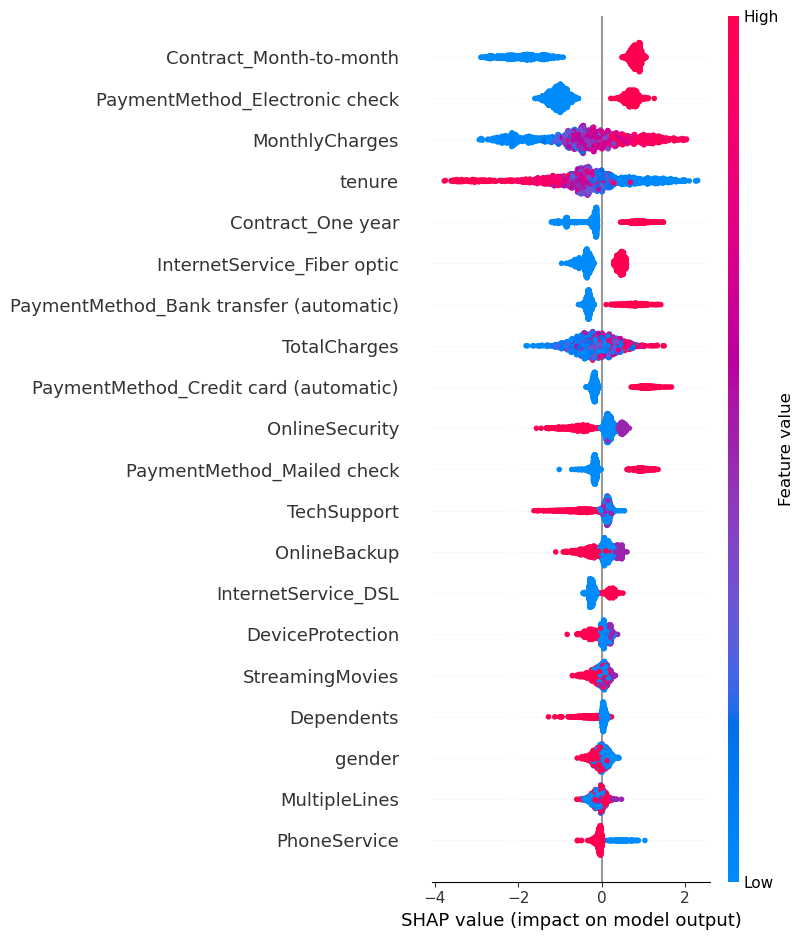

Saved to shap_summary.png


In [8]:
shap.summary_plot(shap_values, X_test, 
                  feature_names=feature_names, 
                  show=False)
plt.savefig('../shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved to shap_summary.png")